# VQA v2.1 - Test Set Prediction

Notebook này sẽ:
1. Load model `best_model_v2.1.pth` đã được train
2. Predict trên test set (chỉ có image + question, không có answers)
3. Export kết quả theo format: `[{"image": "...", "answer": "..."}]`

## Setup

In [1]:
# Fix tokenizers warning
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPModel, CLIPProcessor
from torchvision import transforms

from PIL import Image
import json
import numpy as np
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"🎮 CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📱 GPU: {torch.cuda.get_device_name(0)}")

✅ Libraries imported!
🔥 PyTorch: 2.8.0+cu126
🎮 CUDA: True
📱 GPU: Quadro P1000


## Configuration

In [2]:
# Paths
BASE_DIR = r'e:\Final Clip\vqa_v2.1'
MODEL_PATH = os.path.join(BASE_DIR, 'final.pth')
TEST_IMG_DIR = r'E:\Final Clip\data\test'
TEST_JSON = r'E:\Final Clip\data\Annotations\test.json'
OUTPUT_JSON = os.path.join(BASE_DIR, 'test_predictions.json')

# Model config
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
BATCH_SIZE = 128
NUM_WORKERS = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"⚙️ Configuration:")
print(f"  📁 Model: {MODEL_PATH}")
print(f"  📁 Test images: {TEST_IMG_DIR}")
print(f"  📁 Test JSON: {TEST_JSON}")
print(f"  📁 Output: {OUTPUT_JSON}")
print(f"  🎯 Device: {device}")
print(f"  📊 Batch size: {BATCH_SIZE}")

⚙️ Configuration:
  📁 Model: e:\Final Clip\vqa_v2.1\final.pth
  📁 Test images: E:\Final Clip\data\test
  📁 Test JSON: E:\Final Clip\data\Annotations\test.json
  📁 Output: e:\Final Clip\vqa_v2.1\test_predictions.json
  🎯 Device: cuda
  📊 Batch size: 128


## Model Definition

Định nghĩa lại model architecture giống như lúc training

In [3]:
class AdvancedCLIPVQAModel(nn.Module):
    """Model architecture giống như lúc training"""
    def __init__(self, num_classes, clip_model_name="openai/clip-vit-base-patch32", 
                 unfreeze_layers=1, dropout_rate=0.4):
        super().__init__()
        
        self.num_classes = num_classes
        
        # Load CLIP
        self.clip_model = CLIPModel.from_pretrained(clip_model_name)
        
        # Feature dimensions
        self.vision_dim = 768
        self.text_dim = 512
        
        # Visual Self-Attention
        self.vision_self_attn = nn.MultiheadAttention(
            embed_dim=self.vision_dim, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.vision_self_norm = nn.LayerNorm(self.vision_dim)
        
        # Textual Self-Attention
        self.text_self_attn = nn.MultiheadAttention(
            embed_dim=self.text_dim, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.text_self_norm = nn.LayerNorm(self.text_dim)
        
        # Projection layers
        self.vision_proj = nn.Sequential(
            nn.Linear(self.vision_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.text_proj = nn.Sequential(
            nn.Linear(self.text_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Cross-attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=512, num_heads=8, 
            dropout=dropout_rate, batch_first=True
        )
        self.cross_attn_norm1 = nn.LayerNorm(512)
        self.cross_attn_norm2 = nn.LayerNorm(512)
        self.cross_attn_ffn = nn.Sequential(
            nn.Linear(512, 2048),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(2048, 512),
            nn.Dropout(dropout_rate)
        )
        
        # Fusion network
        self.fusion_net = nn.Sequential(
            nn.Linear(512 * 2, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, pixel_values, questions):
        device = pixel_values.device
        
        # CLIP encoding
        vision_outputs = self.clip_model.vision_model(pixel_values)
        vision_embeddings = vision_outputs.last_hidden_state
        vision_patches = vision_embeddings[:, 1:, :]
        
        text_inputs = {k: v.to(device) for k, v in questions.items()}
        text_outputs = self.clip_model.text_model(**text_inputs)
        text_embeddings = text_outputs.last_hidden_state
        
        # Visual Self-Attention
        vision_self_attended, _ = self.vision_self_attn(
            vision_patches, vision_patches, vision_patches
        )
        vision_refined = self.vision_self_norm(vision_patches + vision_self_attended)
        
        # Textual Self-Attention
        text_self_attended, _ = self.text_self_attn(
            text_embeddings, text_embeddings, text_embeddings
        )
        text_refined = self.text_self_norm(text_embeddings + text_self_attended)
        
        # Project to common space
        vision_proj = self.vision_proj(vision_refined)
        text_proj = self.text_proj(text_refined)
        
        # Cross-attention with Transformer block
        cross_attended, attn_weights = self.cross_attn(
            text_proj, vision_proj, vision_proj
        )
        text_proj = self.cross_attn_norm1(text_proj + cross_attended)
        ffn_output = self.cross_attn_ffn(text_proj)
        text_proj = self.cross_attn_norm2(text_proj + ffn_output)
        
        # Fusion
        text_global = text_proj.mean(dim=1)
        cross_global = text_proj.mean(dim=1)
        fused = torch.cat([text_global, cross_global], dim=1)
        fused = self.fusion_net(fused)
        
        # Classification
        logits = self.classifier(fused)
        
        return logits, attn_weights

print("✅ Model class defined!")

✅ Model class defined!


## Test Dataset

In [4]:
class VQATestDataset(Dataset):
    """Dataset cho test set (không có answers)"""
    
    def __init__(self, image_dir, annotations_file, processor, transform=None):
        self.image_dir = image_dir
        self.processor = processor
        self.transform = transform
        
        # Load annotations
        with open(annotations_file, 'r', encoding='utf-8') as f:
            self.annotations = json.load(f)
        
        print(f"📊 Loaded {len(self.annotations):,} test samples")
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        item = self.annotations[idx]
        
        # Load image
        image_path = os.path.join(self.image_dir, item['image'])
        try:
            image = Image.open(image_path).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))
        
        # Apply transform
        if self.transform:
            image = self.transform(image)
        
        # Process with CLIP
        image_inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = image_inputs['pixel_values'].squeeze(0)
        
        return {
            'pixel_values': pixel_values,
            'question': item['question'],
            'image_name': item['image']
        }

print("✅ Test dataset class defined!")

✅ Test dataset class defined!


## Load Processor

In [5]:
print("🔄 Loading CLIP processor...")
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print("✅ Processor loaded!")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


🔄 Loading CLIP processor...
✅ Processor loaded!


## Create Test DataLoader

In [6]:
# Test transforms (same as validation)
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

# Create test dataset
test_dataset = VQATestDataset(
    image_dir=TEST_IMG_DIR,
    annotations_file=TEST_JSON,
    processor=processor,
    transform=test_transform
)

# Create dataloader
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Test DataLoader created!")
print(f"  📊 Samples: {len(test_dataset):,}")
print(f"  📦 Batches: {len(test_loader):,}")

📊 Loaded 4,319 test samples
✅ Test DataLoader created!
  📊 Samples: 4,319
  📦 Batches: 34


## Load Trained Model

## Verify Checkpoint Structure (Optional)

Run this cell to inspect checkpoint contents if needed

In [7]:
# Optional: Inspect checkpoint to understand its structure
# Uncomment and run if you need to debug

# checkpoint_inspect = torch.load(MODEL_PATH, map_location='cpu')
# print("Checkpoint keys:", checkpoint_inspect.keys())
# 
# if 'model_state_dict' in checkpoint_inspect:
#     state_dict = checkpoint_inspect['model_state_dict']
# else:
#     state_dict = checkpoint_inspect
# 
# print("\nClassifier layers:")
# for key in sorted(state_dict.keys()):
#     if 'classifier' in key:
#         print(f"  {key}: {state_dict[key].shape}")

print("✅ Checkpoint verification cell ready (commented out by default)")

✅ Checkpoint verification cell ready (commented out by default)


In [8]:
print("🔄 Loading trained model...")

# Load checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=device)

print(f"📊 Checkpoint info:")
print(f"   Keys in checkpoint: {list(checkpoint.keys())}")
if 'epoch' in checkpoint:
    print(f"  - Epoch: {checkpoint['epoch'] + 1}")
if 'val_acc' in checkpoint:
    print(f"  - Val Acc: {checkpoint['val_acc']:.2f}%")
if 'val_loss' in checkpoint:
    print(f"  - Val Loss: {checkpoint['val_loss']:.4f}")

# Get model state
model_state = checkpoint.get('model_state_dict', checkpoint)

# Detect num_classes from checkpoint
# Try different possible keys for the final classifier layer
possible_keys = [
    'classifier.6.weight',  # If classifier has 7 layers (0-6)
    'classifier.4.weight',  # If classifier has 5 layers (0-4)
    'classifier.3.weight',
    'classifier.2.weight',
]

classifier_weight = None
for key in possible_keys:
    if key in model_state:
        classifier_weight = model_state[key]
        print(f"  - Found classifier at: {key}")
        break

if classifier_weight is not None:
    num_classes = classifier_weight.shape[0]
    print(f"  - Num classes (output dimension): {num_classes}")
else:
    # Fallback: list all classifier layers
    print("  ⚠️ Could not auto-detect num_classes. Classifier layers found:")
    for key in sorted(model_state.keys()):
        if 'classifier' in key and 'weight' in key:
            print(f"     {key}: shape {model_state[key].shape}")
    
    # Last resort: manually count
    classifier_keys = [k for k in model_state.keys() if 'classifier' in k and 'weight' in k and 'bias' not in k]
    if classifier_keys:
        last_key = sorted(classifier_keys)[-1]
        num_classes = model_state[last_key].shape[0]
        print(f"  - Using last classifier layer: {last_key} -> {num_classes} classes")
    else:
        raise ValueError("Cannot determine num_classes from checkpoint")

# Initialize model
model = AdvancedCLIPVQAModel(
    num_classes=num_classes,
    clip_model_name=CLIP_MODEL_NAME,
    unfreeze_layers=2,
    dropout_rate=0.45
).to(device)

# Load weights
model.load_state_dict(model_state)
model.eval()

print(f"\n✅ Model loaded successfully!")
print(f"  🎯 Ready for prediction on {len(test_dataset):,} samples")


🔄 Loading trained model...
📊 Checkpoint info:
   Keys in checkpoint: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_acc', 'val_loss']
  - Epoch: 18
  - Val Acc: 66.06%
  - Val Loss: 3.0921
  - Found classifier at: classifier.4.weight
  - Num classes (output dimension): 2250

✅ Model loaded successfully!
  🎯 Ready for prediction on 4,319 samples


## Load Answer Vocabulary

Load idx_to_answer mapping từ checkpoint hoặc từ training data.

**Important:** 
- Nếu checkpoint không chứa `idx_to_answer`, ta phải rebuild từ training data
- Số lượng answers phải khớp với `num_classes` của model (output layer size)
- Thông thường VQA models dùng top 100 most common answers

## ⚠️ Giải thích quan trọng về idx_to_answer

**Tại sao cần idx_to_answer?**

VQA model là **classification**, không phải text generation:
- Model output: logits với shape `[batch_size, num_classes]` 
- Mỗi class index (0, 1, 2, ...) → một câu trả lời cụ thể
- Model chỉ học predict **số index**, không phải text

**Ví dụ:**
- Model predict index `5` → Cần mapping `idx_to_answer[5] = "2"` để biết câu trả lời là "2"
- Nếu mapping sai: model predict đúng index 5, nhưng bạn map thành "cat" → SAI!

**Giải pháp:**
1. ✅ **Tốt nhất:** Lưu `idx_to_answer` vào checkpoint khi training
2. ⚠️ **Fallback:** Rebuild từ train.json (phải đảm bảo thứ tự giống hệt lúc training)

**Kiểm tra:** Xem checkpoint có chứa `idx_to_answer` không ở cell dưới đây.

In [9]:
# VERIFICATION: So sánh idx_to_answer từ checkpoint vs rebuild từ train.json
print("🔍 VERIFICATION: Checking idx_to_answer consistency")
print("="*60)

# Load từ checkpoint
checkpoint_mapping = checkpoint.get('idx_to_answer', None)

if checkpoint_mapping:
    print("✅ Checkpoint has idx_to_answer:")
    print(f"   Number of answers: {len(checkpoint_mapping)}")
    print(f"   Sample answers: {list(checkpoint_mapping.values())[:10]}")
    idx_to_answer = checkpoint_mapping
else:
    print("⚠️ Checkpoint does NOT have idx_to_answer")
    print("   Will rebuild from train.json...")
    
    # Rebuild từ train.json
    from collections import Counter
    TRAIN_JSON = r'E:\Final Clip\data\Annotations\train.json'
    
    with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
        train_data = json.load(f)
    
    answer_counts = Counter()
    for item in train_data:
        if 'answers' in item:
            for ans_obj in item['answers']:
                answer_counts[ans_obj['answer'].lower().strip()] += 1
    
    most_common = answer_counts.most_common(num_classes)
    rebuilt_mapping = {idx: ans for idx, (ans, _) in enumerate(most_common)}
    
    print(f"   Rebuilt {len(rebuilt_mapping)} answers from train.json")
    print(f"   Sample answers: {list(rebuilt_mapping.values())[:10]}")
    
    # So sánh nếu có cả hai
    if checkpoint_mapping and rebuilt_mapping:
        matches = sum(1 for i in range(min(len(checkpoint_mapping), len(rebuilt_mapping))) 
                     if checkpoint_mapping.get(i) == rebuilt_mapping.get(i))
        print(f"\n📊 Consistency check:")
        print(f"   Matching indices: {matches}/{len(rebuilt_mapping)} ({100*matches/len(rebuilt_mapping):.1f}%)")
        
        if matches < len(rebuilt_mapping):
            print("   ⚠️ WARNING: Mappings DO NOT MATCH completely!")
            print("   This means predictions may be INCORRECT!")
            print("\n   First 5 mismatches:")
            for i in range(min(5, len(rebuilt_mapping))):
                if checkpoint_mapping.get(i) != rebuilt_mapping.get(i):
                    print(f"     idx {i}: checkpoint='{checkpoint_mapping.get(i)}' vs rebuilt='{rebuilt_mapping.get(i)}'")
    
    idx_to_answer = rebuilt_mapping
    
    # Optionally save back to checkpoint
    if not checkpoint_mapping:
        print(f"\n💾 Saving idx_to_answer to checkpoint...")
        checkpoint['idx_to_answer'] = idx_to_answer
        torch.save(checkpoint, MODEL_PATH)
        print(f"✅ Checkpoint updated!")

print(f"\n✅ Using idx_to_answer with {len(idx_to_answer)} classes")
print(f"   Model output size: {num_classes}")
print(f"   Match: {'✅ YES' if len(idx_to_answer) == num_classes else '❌ NO - PROBLEM!'}")

🔍 VERIFICATION: Checking idx_to_answer consistency
⚠️ Checkpoint does NOT have idx_to_answer
   Will rebuild from train.json...
   Rebuilt 2250 answers from train.json
   Sample answers: ['unanswerable', 'no', 'yes', 'white', 'grey', 'black', 'blue', 'red', 'brown', 'pink']

💾 Saving idx_to_answer to checkpoint...
✅ Checkpoint updated!

✅ Using idx_to_answer with 2250 classes
   Model output size: 2250
   Match: ✅ YES


## Prediction Function

In [10]:
def predict_single(model, image, question, processor, idx_to_answer, device):
    """
    Predict cho một cặp image-question
    Đơn giản như demo trong notebook training
    """
    # Process image
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)
    
    # Tokenize question
    tokenized_question = processor.tokenizer(
        question,
        padding=True,
        truncation=True,
        max_length=77,
        return_tensors="pt"
    )
    
    # Forward pass
    with torch.no_grad():
        logits, _ = model(pixel_values, tokenized_question)
        probs = F.softmax(logits, dim=-1)
        pred_idx = torch.argmax(probs, dim=-1).item()
    
    # Get answer
    pred_answer = idx_to_answer.get(pred_idx, "unknown")
    
    return pred_answer

print("✅ Prediction function defined!")

✅ Prediction function defined!


## Run Prediction

In [11]:
print("🚀 Starting prediction on test set...")
print("="*60)

import time
start_time = time.time()

# Load test annotations
with open(TEST_JSON, 'r', encoding='utf-8') as f:
    test_annotations = json.load(f)

print(f"📊 Total test samples: {len(test_annotations):,}")

# Predict từng sample
predictions = []

for i, item in enumerate(tqdm(test_annotations, desc='Predicting')):
    image_name = item['image']
    question = item['question']
    
    # Load image
    image_path = os.path.join(TEST_IMG_DIR, image_name)
    try:
        image = Image.open(image_path).convert('RGB')
    except:
        # Nếu không load được, dùng ảnh trắng
        image = Image.new('RGB', (224, 224), color=(255, 255, 255))
    
    # Predict
    pred_answer = predict_single(
        model=model,
        image=image,
        question=question,
        processor=processor,
        idx_to_answer=idx_to_answer,
        device=device
    )
    
    # Lưu kết quả
    predictions.append({
        "image": image_name,
        "answer": pred_answer
    })

elapsed_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"✅ Prediction completed!")
print(f"  ⏱️ Time: {elapsed_time:.2f}s ({elapsed_time/len(predictions)*1000:.2f}ms per sample)")
print(f"  📊 Total predictions: {len(predictions):,}")
print(f"{'='*60}")

🚀 Starting prediction on test set...
📊 Total test samples: 4,319


Predicting:   0%|          | 0/4319 [00:00<?, ?it/s]


✅ Prediction completed!
  ⏱️ Time: 359.30s (83.19ms per sample)
  📊 Total predictions: 4,319


## Save Results

In [12]:
print(f"💾 Saving predictions to: {OUTPUT_JSON}")

# Save to JSON
with open(OUTPUT_JSON, 'w', encoding='utf-8') as f:
    json.dump(predictions, f, indent=2, ensure_ascii=False)

print(f"✅ Saved {len(predictions):,} predictions!")

# Display first 10 predictions
print(f"\n📋 First 10 predictions:")
print("="*60)
for i, pred in enumerate(predictions[:10], 1):
    print(f"{i}. Image: {pred['image']}")
    print(f"   Answer: {pred['answer']}\n")

💾 Saving predictions to: e:\Final Clip\vqa_v2.1\test_predictions.json
✅ Saved 4,319 predictions!

📋 First 10 predictions:
1. Image: VizWiz_val_00000000.jpg
   Answer: unanswerable

2. Image: VizWiz_val_00000001.jpg
   Answer: unanswerable

3. Image: VizWiz_val_00000002.jpg
   Answer: unanswerable

4. Image: VizWiz_val_00000003.jpg
   Answer: left

5. Image: VizWiz_val_00000004.jpg
   Answer: unanswerable

6. Image: VizWiz_val_00000005.jpg
   Answer: unanswerable

7. Image: VizWiz_val_00000006.jpg
   Answer: unanswerable

8. Image: VizWiz_val_00000007.jpg
   Answer: unanswerable

9. Image: VizWiz_val_00000008.jpg
   Answer: unanswerable

10. Image: VizWiz_val_00000009.jpg
   Answer: unanswerable



## Answer Distribution Analysis

📊 Answer Distribution (Top 20):
 1. unanswerable        :  3146 (72.84%)
 2. no                  :   178 ( 4.12%)
 3. white               :    80 ( 1.85%)
 4. cereal              :    71 ( 1.64%)
 5. black               :    62 ( 1.44%)
 6. soup                :    61 ( 1.41%)
 7. blue                :    60 ( 1.39%)
 8. yes                 :    59 ( 1.37%)
 9. laptop              :    50 ( 1.16%)
10. grey                :    46 ( 1.07%)
11. red                 :    44 ( 1.02%)
12. phone               :    29 ( 0.67%)
13. brown               :    25 ( 0.58%)
14. chicken             :    23 ( 0.53%)
15. chair               :    21 ( 0.49%)
16. dog                 :    21 ( 0.49%)
17. water bottle        :    20 ( 0.46%)
18. tv                  :    17 ( 0.39%)
19. keyboard            :    16 ( 0.37%)
20. hand sanitizer      :    16 ( 0.37%)


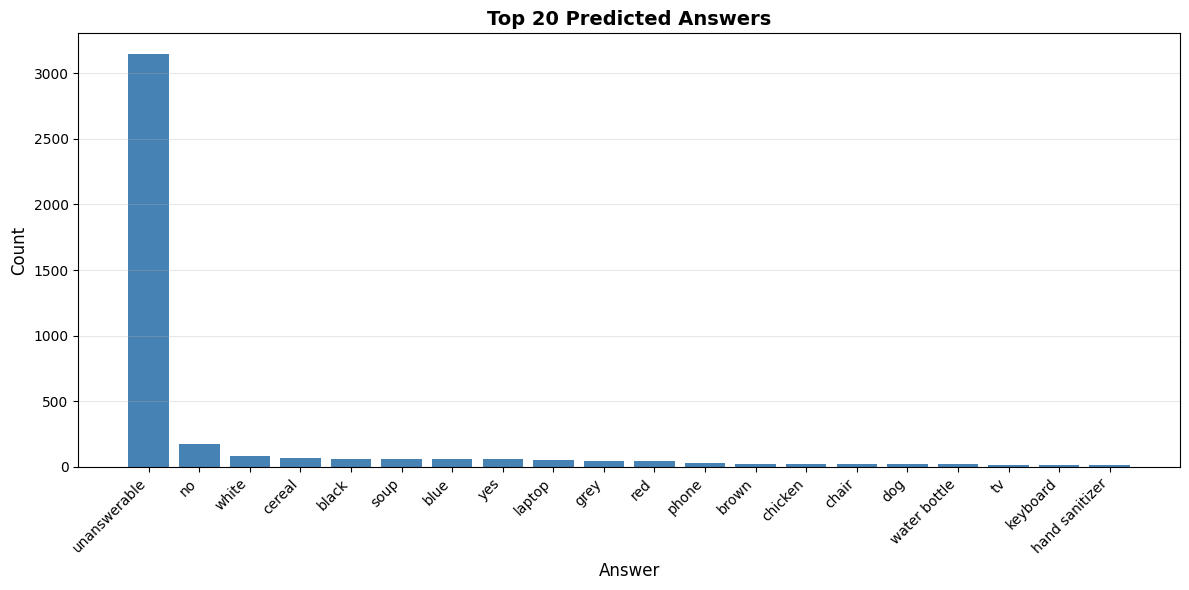


✅ Distribution plot saved!


In [13]:
from collections import Counter
import matplotlib.pyplot as plt

# Count answer distribution
answer_counts = Counter([pred['answer'] for pred in predictions])
top_20 = answer_counts.most_common(20)

print(f"📊 Answer Distribution (Top 20):")
print("="*60)
for i, (answer, count) in enumerate(top_20, 1):
    pct = 100 * count / len(predictions)
    print(f"{i:2d}. {answer:20s}: {count:5d} ({pct:5.2f}%)")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
answers, counts = zip(*top_20)
ax.bar(range(len(answers)), counts, color='steelblue')
ax.set_xticks(range(len(answers)))
ax.set_xticklabels(answers, rotation=45, ha='right')
ax.set_xlabel('Answer', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Top 20 Predicted Answers', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'test_predictions_distribution.png'), dpi=150)
plt.show()

print(f"\n✅ Distribution plot saved!")

## Visualize Sample Predictions

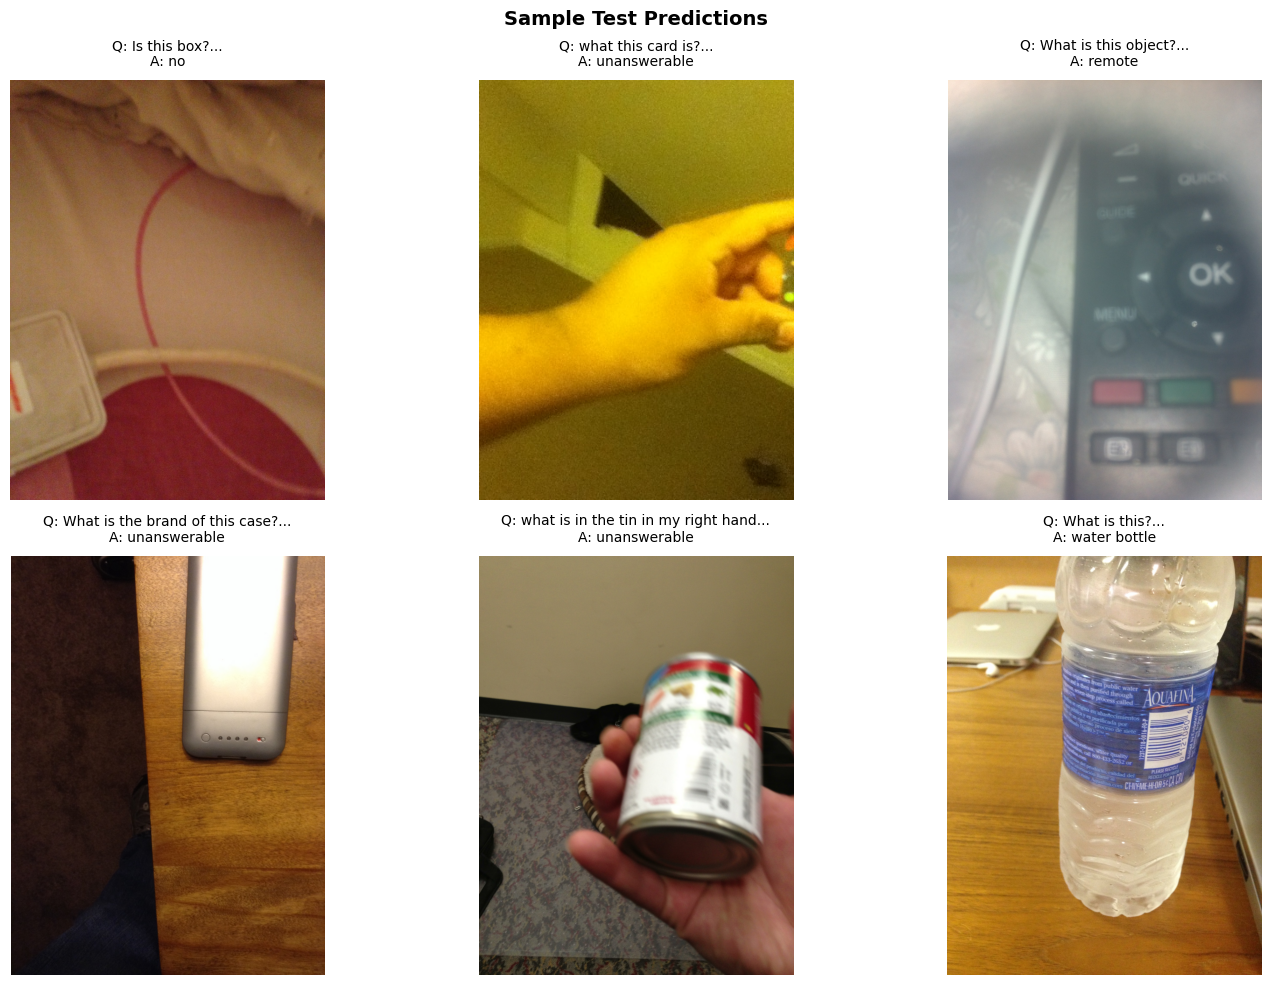

✅ Sample visualization saved!


In [14]:
# Visualize random samples
import random

NUM_SAMPLES = 6
sample_indices = random.sample(range(len(predictions)), NUM_SAMPLES)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    pred = predictions[sample_idx]
    test_item = test_dataset.annotations[sample_idx]
    
    # Load image
    img_path = os.path.join(TEST_IMG_DIR, pred['image'])
    try:
        img = Image.open(img_path).convert('RGB')
    except:
        img = Image.new('RGB', (224, 224), color=(200, 200, 200))
    
    # Display
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    title = f"Q: {test_item['question'][:40]}...\n"
    title += f"A: {pred['answer']}"
    axes[idx].set_title(title, fontsize=10, pad=10)

plt.suptitle('Sample Test Predictions', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'test_predictions_samples.png'), dpi=150)
plt.show()

print("✅ Sample visualization saved!")

## Summary

In [15]:
print("\n" + "="*60)
print("🎉 PREDICTION SUMMARY")
print("="*60)
print(f"\n📁 Files:")
print(f"  - Model: {MODEL_PATH}")
print(f"  - Test images: {TEST_IMG_DIR}")
print(f"  - Test annotations: {TEST_JSON}")
print(f"  - Output predictions: {OUTPUT_JSON}")

print(f"\n📊 Statistics:")
print(f"  - Total test samples: {len(predictions):,}")
print(f"  - Unique answers predicted: {len(answer_counts):,}")
print(f"  - Most common answer: {top_20[0][0]} ({top_20[0][1]:,} times, {100*top_20[0][1]/len(predictions):.2f}%)")
print(f"  - Prediction time: {elapsed_time:.2f}s")
print(f"  - Speed: {elapsed_time/len(predictions)*1000:.2f}ms per sample")

print(f"\n✅ Prediction completed successfully!")
print(f"💾 Results saved to: {OUTPUT_JSON}")
print("="*60)


🎉 PREDICTION SUMMARY

📁 Files:
  - Model: e:\Final Clip\vqa_v2.1\final.pth
  - Test images: E:\Final Clip\data\test
  - Test annotations: E:\Final Clip\data\Annotations\test.json
  - Output predictions: e:\Final Clip\vqa_v2.1\test_predictions.json

📊 Statistics:
  - Total test samples: 4,319
  - Unique answers predicted: 75
  - Most common answer: unanswerable (3,146 times, 72.84%)
  - Prediction time: 359.30s
  - Speed: 83.19ms per sample

✅ Prediction completed successfully!
💾 Results saved to: e:\Final Clip\vqa_v2.1\test_predictions.json
